
Top Features:

         Feature  Importance
5    cholesterol    0.147315
4        glucose    0.139244
1            bmi    0.134539
6     creatinine    0.120662
0            age    0.114609
2    systolic_bp    0.111693
3   diastolic_bp    0.107819
8   hypertension    0.019683
7       diabetes    0.015248
11      sex_Male    0.014882


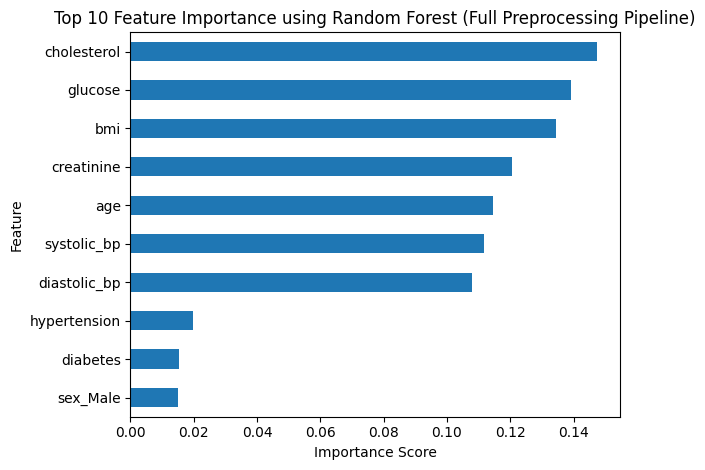

In [8]:
# RQ4: FEATURE IMPORTANCE 

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split

df = pd.read_csv('/kaggle/input/datasets/uom190346a/synthetic-clinical-tabular-dataset/synthetic_clinical_dataset.csv')

# REMOVE ID COLUMN

X = df.drop(columns=['mortality', 'patient_id'])
y = df['mortality']


# TRAIN TEST SPLIT (important)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)


# COLUMN TYPES

numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = X.select_dtypes(include=['object']).columns


# FULL PIPELINE

numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

full_preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

model = Pipeline([
    ('preprocessor', full_preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])


# TRAIN MODEL

model.fit(X_train, y_train)


# FEATURE NAMES

num_features = list(numeric_cols)

cat_features = model.named_steps['preprocessor']\
    .named_transformers_['cat']\
    .get_feature_names_out(categorical_cols)

feature_names = np.concatenate([num_features, cat_features])


# FEATURE IMPORTANCE

importances = model.named_steps['model'].feature_importances_

feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Top 10
top_features = feat_df.head(10)

print("\nTop Features:\n")
print(top_features)


# SAVE TABLE

top_features.to_csv("rq4_top_features.csv", index=False)


# PLOT

top_features.set_index('Feature')['Importance'].plot(kind='barh')

plt.title("Top 10 Feature Importance using Random Forest (Full Preprocessing Pipeline)")
plt.xlabel("Importance Score")
plt.gca().invert_yaxis()
plt.tight_layout()

plt.savefig("rq4_feature_importance.pdf")
plt.show()